In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Create a sample weather dataset

import pandas as pd
import numpy as np

np.random.seed(42)

dates = pd.date_range(start="2023-01-01", periods=10000, freq="h")

weather_data = pd.DataFrame({
    "Date": dates,
    "Temperature": np.random.uniform(10, 45, 10000),
    "Rainfall": np.random.uniform(0, 50, 10000),
    "Humidity": np.random.uniform(30, 95, 10000)
})

weather_data.head()

,Date,Temperature,Rainfall,Humidity
0,2023-01-01 00:00:00,23.108904,18.682041,77.449890
1,2023-01-01 01:00:00,43.275001,16.645605,41.993280
2,2023-01-01 02:00:00,35.619788,8.807696,52.531580
3,2023-01-01 03:00:00,30.953047,30.363334,73.113241
4,2023-01-01 04:00:00,15.460652,23.831208,61.335807


In [ ]:
print("Number of records:", len(weather_data))
print("Number of columns:", len(weather_data.columns))

weather_data.info()

Number of records: 10000
Number of columns: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         10000 non-null  datetime64[ns]
 1   Temperature  10000 non-null  float64       
 2   Rainfall     10000 non-null  float64       
 3   Humidity     10000 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 312.6 KB


In [ ]:
# Check missing values

print("Missing values in each column:")
print(weather_data.isnull().sum())

Missing values in each column:
Date           0
Temperature    0
Rainfall       0
Humidity       0
dtype: int64


In [ ]:
# Check duplicate records

print("Number of duplicate records:",
      weather_data.duplicated().sum())# Check date range

print("Starting date:", weather_data["Date"].min())
print("Ending date:", weather_data["Date"].max())

Number of duplicate records: 0
Starting date: 2023-01-01 00:00:00
Ending date: 2024-02-21 15:00:00


In [ ]:
# Calculate average temperature

average_temperature = weather_data["Temperature"].mean()

print("Average Temperature:", round(average_temperature, 2), "°C")

Average Temperature: 27.3 °C


In [ ]:
# Find maximum and minimum temperature

max_temperature = weather_data["Temperature"].max()
min_temperature = weather_data["Temperature"].min()

print("Maximum Temperature:", round(max_temperature, 2), "°C")
print("Minimum Temperature:", round(min_temperature, 2), "°C")

Maximum Temperature: 44.99 °C
Minimum Temperature: 10.0 °C


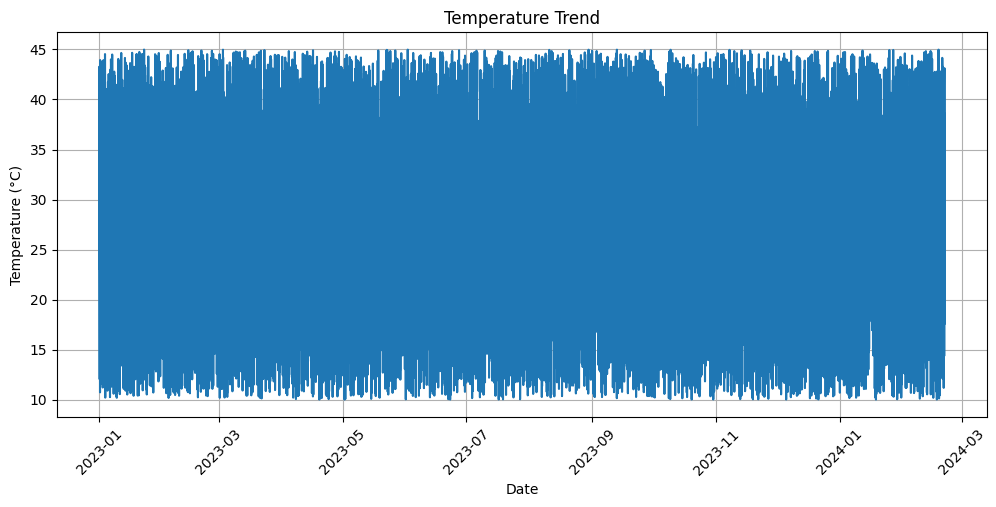

In [ ]:
# Temperature trend

plt.figure(figsize=(12, 5))

plt.plot(
    weather_data["Date"],
    weather_data["Temperature"]
)

plt.title("Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Calculate average rainfall

average_rainfall = weather_data["Rainfall"].mean()

print("Average Rainfall:", round(average_rainfall, 2))


Average Rainfall: 25.23


In [ ]:
# Calculate total rainfall

total_rainfall = weather_data["Rainfall"].sum()

print("Total Rainfall:", round(total_rainfall, 2))

Total Rainfall: 252264.94


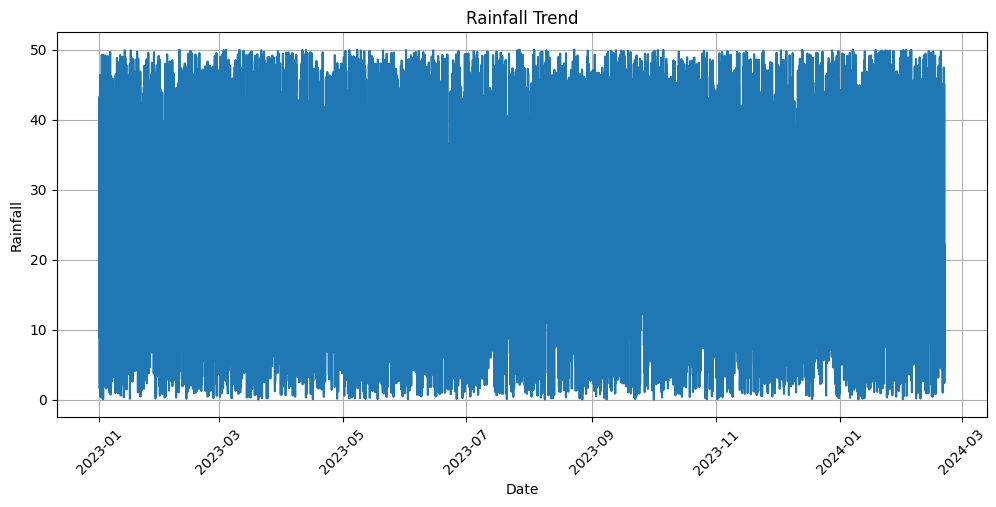

In [ ]:
# Rainfall trend

plt.figure(figsize=(12, 5))

plt.plot(
    weather_data["Date"],
    weather_data["Rainfall"]
)

plt.title("Rainfall Trend")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Extract month from Date

weather_data["Month"] = weather_data["Date"].dt.month

weather_data["Month_Name"] = weather_data["Date"].dt.month_name()

weather_data.head()

,Date,Temperature,Rainfall,Humidity,Month,Month_Name
0,2023-01-01 00:00:00,23.108904,18.682041,77.449890,1,January
1,2023-01-01 01:00:00,43.275001,16.645605,41.993280,1,January
2,2023-01-01 02:00:00,35.619788,8.807696,52.531580,1,January
3,2023-01-01 03:00:00,30.953047,30.363334,73.113241,1,January
4,2023-01-01 04:00:00,15.460652,23.831208,61.335807,1,January


In [ ]:
# Create seasons

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Autumn"

weather_data["Season"] = weather_data["Month"].apply(get_season)

weather_data.head()

,Date,Temperature,Rainfall,Humidity,Month,Month_Name,Season
0,2023-01-01 00:00:00,23.108904,18.682041,77.449890,1,January,Winter
1,2023-01-01 01:00:00,43.275001,16.645605,41.993280,1,January,Winter
2,2023-01-01 02:00:00,35.619788,8.807696,52.531580,1,January,Winter
3,2023-01-01 03:00:00,30.953047,30.363334,73.113241,1,January,Winter
4,2023-01-01 04:00:00,15.460652,23.831208,61.335807,1,January,Winter


In [ ]:
# Average temperature by season

season_temperature = weather_data.groupby("Season")["Temperature"].mean()

print(season_temperature)

Season
Autumn     27.000908
Monsoon    27.305229
Summer     27.489490
Winter     27.288238
Name: Temperature, dtype: float64


In [ ]:
# Average rainfall by season

season_rainfall = weather_data.groupby("Season")["Rainfall"].mean()

print(season_rainfall)

Season
Autumn     25.692498
Monsoon    25.007521
Summer     24.766325
Winter     25.513252
Name: Rainfall, dtype: float64


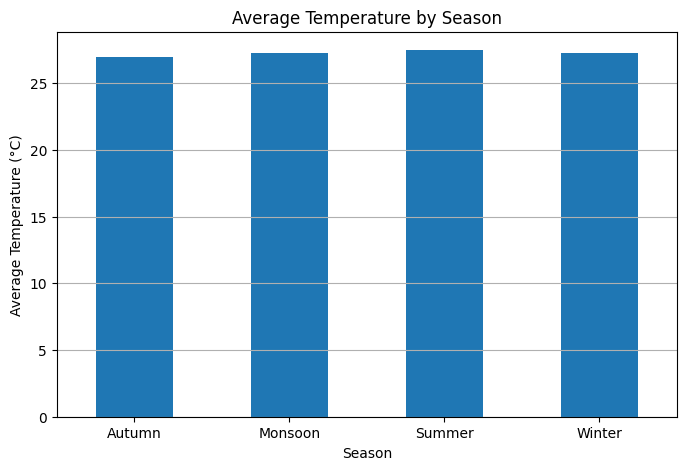

In [ ]:
# Seasonal temperature comparison

plt.figure(figsize=(8, 5))

season_temperature.plot(kind="bar")

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

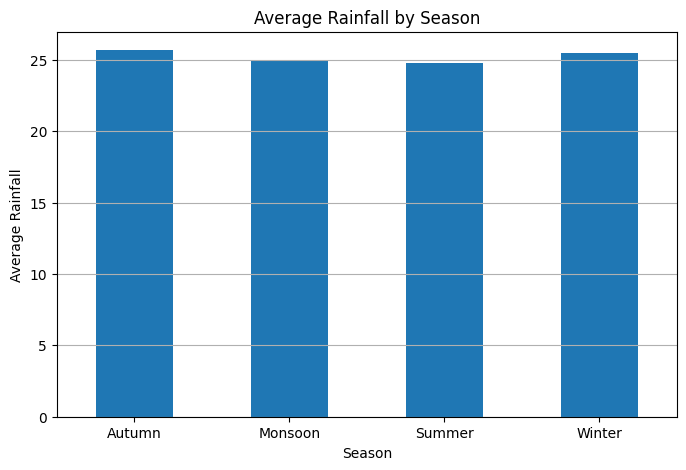

In [ ]:
# Seasonal rainfall comparison

plt.figure(figsize=(8, 5))

season_rainfall.plot(kind="bar")

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Average Rainfall")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [ ]:
# Calculate monthly average temperature

monthly_temperature = weather_data.groupby("Month_Name")["Temperature"].mean()

print(monthly_temperature)

Month_Name
April        27.381832
August       27.443637
December     26.931907
February     27.330251
January      27.433426
July         27.282599
June         27.095487
March        27.579628
May          27.503539
November     26.732879
October      27.260291
September    27.395333
Name: Temperature, dtype: float64


In [ ]:
# Correct month order

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_temperature = (
    weather_data.groupby("Month_Name")["Temperature"]
    .mean()
    .reindex(month_order)
)

monthly_temperature

,Temperature
Month_Name,
January,27.433426
February,27.330251
March,27.579628
April,27.381832
May,27.503539
June,27.095487
July,27.282599
August,27.443637
September,27.395333


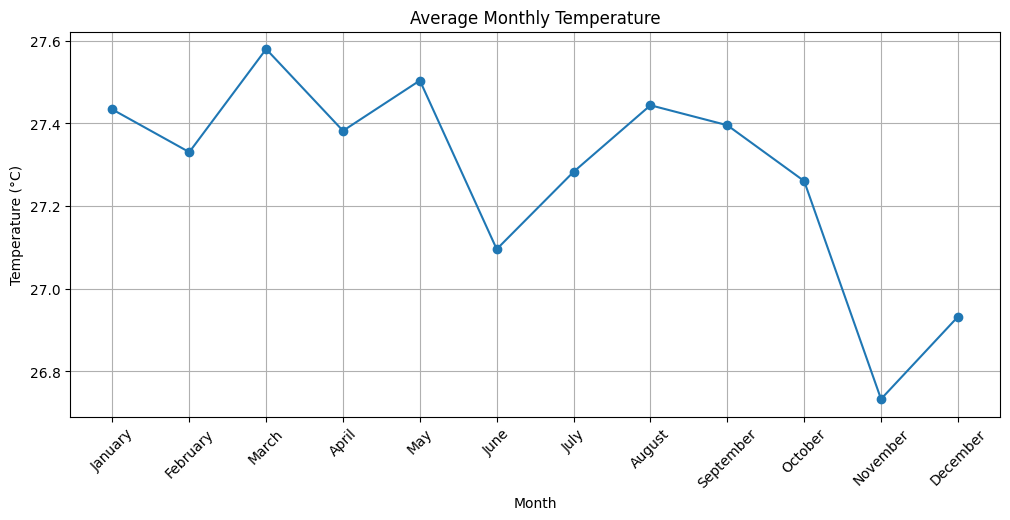

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_temperature.index,
    monthly_temperature.values,
    marker="o"
)

plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# Calculate monthly average rainfall

monthly_rainfall = (
    weather_data.groupby("Month_Name")["Rainfall"]
    .mean()
    .reindex(month_order)
)

monthly_rainfall

,Rainfall
Month_Name,
January,25.469702
February,25.313637
March,25.117492
April,24.653578
May,24.524266
June,24.798747
July,25.352892
August,24.790022
September,25.084160


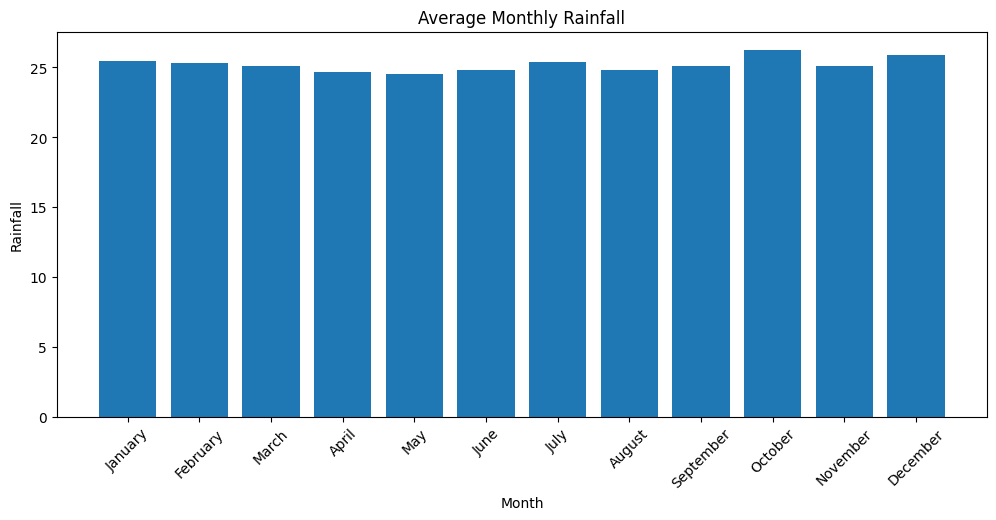

In [ ]:
plt.figure(figsize=(12, 5))

plt.bar(
    monthly_rainfall.index,
    monthly_rainfall.values
)

plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Highest temperature record

highest_temp = weather_data.loc[
    weather_data["Temperature"].idxmax()
]

print("Highest Temperature Record:")
print(highest_temp)

Highest Temperature Record:
Date           2023-01-23 03:00:00
Temperature              44.990119
Rainfall                 37.939707
Humidity                 67.830603
Month                            1
Month_Name                 January
Season                      Winter
Name: 531, dtype: object


In [ ]:
# Lowest temperature record

lowest_temp = weather_data.loc[
    weather_data["Temperature"].idxmin()
]

print("Lowest Temperature Record:")
print(lowest_temp)

Lowest Temperature Record:
Date           2023-05-01 22:00:00
Temperature              10.000407
Rainfall                  1.948618
Humidity                 90.164614
Month                            5
Month_Name                     May
Season                      Summer
Name: 2902, dtype: object


In [ ]:
# Highest rainfall record

highest_rainfall = weather_data.loc[
    weather_data["Rainfall"].idxmax()
]

print("Highest Rainfall Record:")
print(highest_rainfall)

Highest Rainfall Record:
Date           2023-08-23 02:00:00
Temperature              29.269972
Rainfall                 49.996241
Humidity                 60.110388
Month                            8
Month_Name                  August
Season                     Monsoon
Name: 5618, dtype: object


In [ ]:
# Select numerical columns

numeric_data = weather_data[
    ["Temperature", "Rainfall", "Humidity"]
]

correlation = numeric_data.corr()

print(correlation)

             Temperature  Rainfall  Humidity
Temperature     1.000000 -0.005125 -0.009346
Rainfall       -0.005125  1.000000 -0.024219
Humidity       -0.009346 -0.024219  1.000000


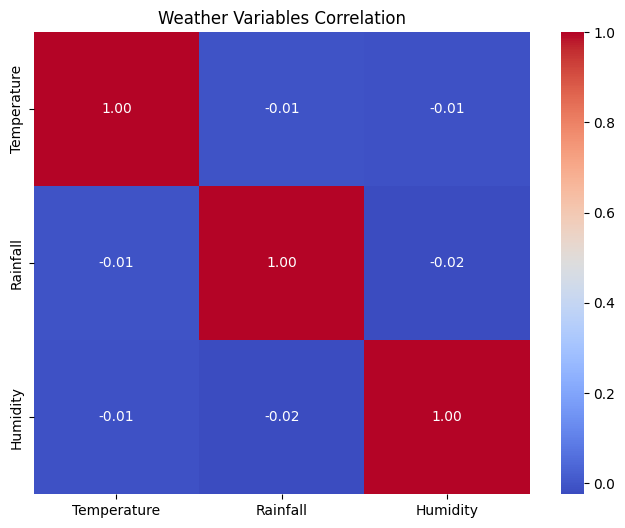

In [ ]:
# Create correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Weather Variables Correlation")
plt.show()

In [ ]:
# Project summary

print("===== WEATHER DATA ANALYSIS SUMMARY =====")
print("Total Records:", len(weather_data))
print("Average Temperature:",
      round(weather_data["Temperature"].mean(), 2), "°C")
print("Maximum Temperature:",
      round(weather_data["Temperature"].max(), 2), "°C")
print("Minimum Temperature:",
      round(weather_data["Temperature"].min(), 2), "°C")
print("Average Rainfall:",
      round(weather_data["Rainfall"].mean(), 2))
print("Average Humidity:",
      round(weather_data["Humidity"].mean(), 2))

===== WEATHER DATA ANALYSIS SUMMARY =====
Total Records: 10000
Average Temperature: 27.3 °C
Maximum Temperature: 44.99 °C
Minimum Temperature: 10.0 °C
Average Rainfall: 25.23
Average Humidity: 62.5


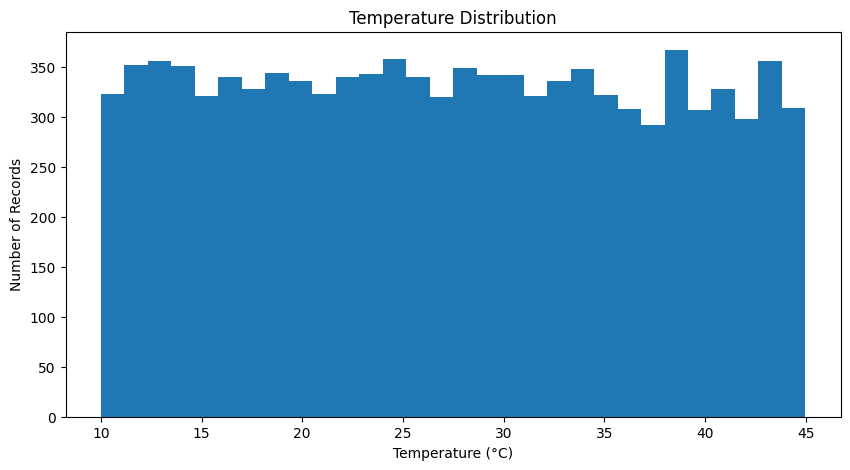

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(weather_data["Temperature"], bins=30)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of Records")

plt.show()

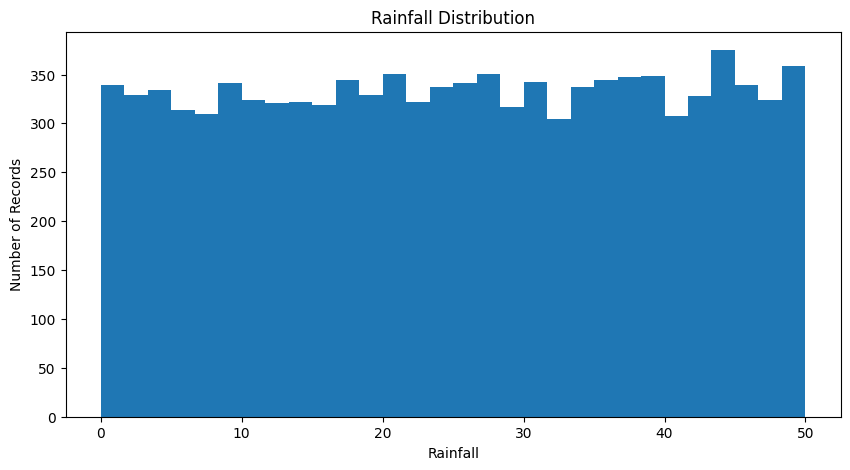

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(weather_data["Rainfall"], bins=30)

plt.title("Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Number of Records")

plt.show()

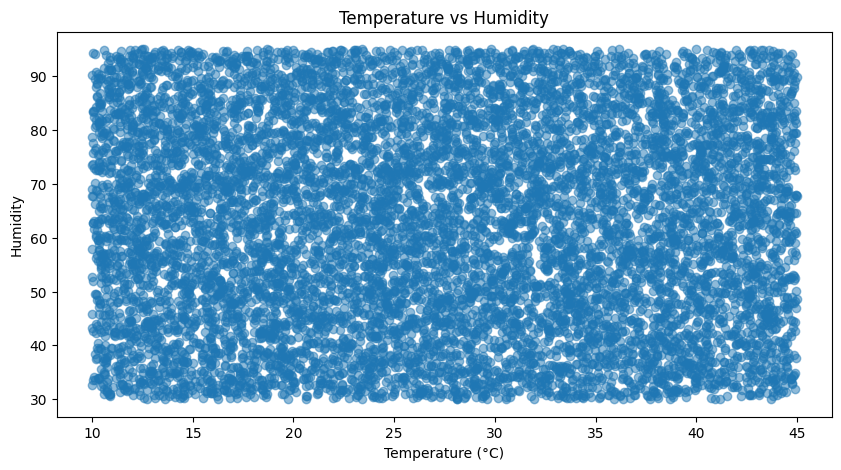

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(
    weather_data["Temperature"],
    weather_data["Humidity"],
    alpha=0.5
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity")

plt.show()

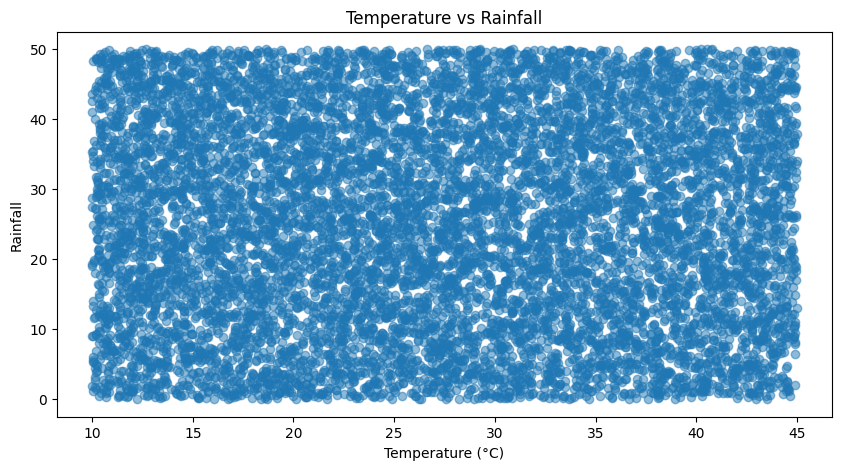

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(
    weather_data["Temperature"],
    weather_data["Rainfall"],
    alpha=0.5
)

plt.title("Temperature vs Rainfall")
plt.xlabel("Temperature (°C)")
plt.ylabel("Rainfall")

plt.show()

In [ ]:
# Save the analyzed dataset

weather_data.to_csv(
    "weather_analysis_final.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [ ]:
# Final project findings

avg_temp = weather_data["Temperature"].mean()
max_temp = weather_data["Temperature"].max()
min_temp = weather_data["Temperature"].min()

avg_rainfall = weather_data["Rainfall"].mean()
max_rainfall = weather_data["Rainfall"].max()

highest_temp_date = weather_data.loc[
    weather_data["Temperature"].idxmax(), "Date"
]

lowest_temp_date = weather_data.loc[
    weather_data["Temperature"].idxmin(), "Date"
]

highest_rainfall_date = weather_data.loc[
    weather_data["Rainfall"].idxmax(), "Date"
]

print("========== FINAL FINDINGS ==========")

print(f"1. The dataset contains {len(weather_data):,} weather records.")

print(f"2. The average temperature was {avg_temp:.2f} °C.")

print(f"3. The maximum temperature was {max_temp:.2f} °C "
      f"on {highest_temp_date}.")

print(f"4. The minimum temperature was {min_temp:.2f} °C "
      f"on {lowest_temp_date}.")

print(f"5. The average rainfall was {avg_rainfall:.2f}.")

print(f"6. The highest recorded rainfall was {max_rainfall:.2f} "
      f"on {highest_rainfall_date}.")

print("7. Monthly and seasonal analysis was performed "
      "to identify weather patterns.")

print("8. Correlation analysis was used to examine "
      "relationships between temperature, rainfall, and humidity.")

========== FINAL FINDINGS ==========
1. The dataset contains 10,000 weather records.
2. The average temperature was 27.30 °C.
3. The maximum temperature was 44.99 °C on 2023-01-23 03:00:00.
4. The minimum temperature was 10.00 °C on 2023-05-01 22:00:00.
5. The average rainfall was 25.23.
6. The highest recorded rainfall was 50.00 on 2023-08-23 02:00:00.
7. Monthly and seasonal analysis was performed to identify weather patterns.
8. Correlation analysis was used to examine relationships between temperature, rainfall, and humidity.


In [ ]:
print("""
========== PROJECT CONCLUSION ==========

The Weather Data Analysis project analyzed 10,000
weather records using Python, Pandas, NumPy,
Matplotlib, and Seaborn.

The analysis focused on temperature, rainfall,
humidity, monthly trends, seasonal variations,
and relationships between weather variables.

Data cleaning and exploratory data analysis were
performed to identify meaningful weather patterns
through statistical analysis and visualization.
""")


========== PROJECT CONCLUSION ==========

The Weather Data Analysis project analyzed 10,000
weather records using Python, Pandas, NumPy,
Matplotlib, and Seaborn.

The analysis focused on temperature, rainfall,
humidity, monthly trends, seasonal variations,
and relationships between weather variables.

Data cleaning and exploratory data analysis were
performed to identify meaningful weather patterns
through statistical analysis and visualization.

